In [19]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [20]:
df = pd.read_csv('bank.csv')

In [21]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343.0,yes,no,unknown,5.0,may,1042.0,1.0,-1.0,0.0,unknown,yes
1,56,admin.,married,secondary,no,45.0,no,no,unknown,5.0,may,1467.0,1.0,-1.0,0.0,unknown,yes
2,41,technician,married,secondary,no,1270.0,yes,no,unknown,5.0,may,1389.0,1.0,-1.0,0.0,unknown,yes
3,54,admin.,married,tertiary,no,184.0,no,no,unknown,5.0,may,673.0,2.0,-1.0,0.0,unknown,yes
4,42,management,single,tertiary,no,0.0,yes,yes,unknown,5.0,may,562.0,2.0,-1.0,0.0,unknown,yes


In [22]:
df.shape

(8912, 17)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8912 entries, 0 to 8911
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        8912 non-null   int64  
 1   job        8905 non-null   object 
 2   marital    8743 non-null   object 
 3   education  8885 non-null   object 
 4   default    8908 non-null   object 
 5   balance    8899 non-null   float64
 6   housing    8899 non-null   object 
 7   loan       8882 non-null   object 
 8   contact    8881 non-null   object 
 9   day        8893 non-null   float64
 10  month      8884 non-null   object 
 11  duration   8905 non-null   float64
 12  campaign   8904 non-null   float64
 13  pdays      8767 non-null   float64
 14  previous   8909 non-null   float64
 15  poutcome   8912 non-null   object 
 16  deposit    8903 non-null   object 
dtypes: float64(6), int64(1), object(10)
memory usage: 1.2+ MB


In [24]:
df.isnull().sum()

age            0
job            7
marital      169
education     27
default        4
balance       13
housing       13
loan          30
contact       31
day           19
month         28
duration       7
campaign       8
pdays        145
previous       3
poutcome       0
deposit        9
dtype: int64

In [25]:
for col in df.columns:
    
    if df[col].dtype != 'object':
        
        df[col] = df[col].fillna(df[col].median())
    
    else:
        
        df[col] = df[col].fillna(df[col].mode()[0])

In [26]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [27]:
df.drop_duplicates(inplace=True)

In [28]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    
    df[col] = le.fit_transform(df[col])

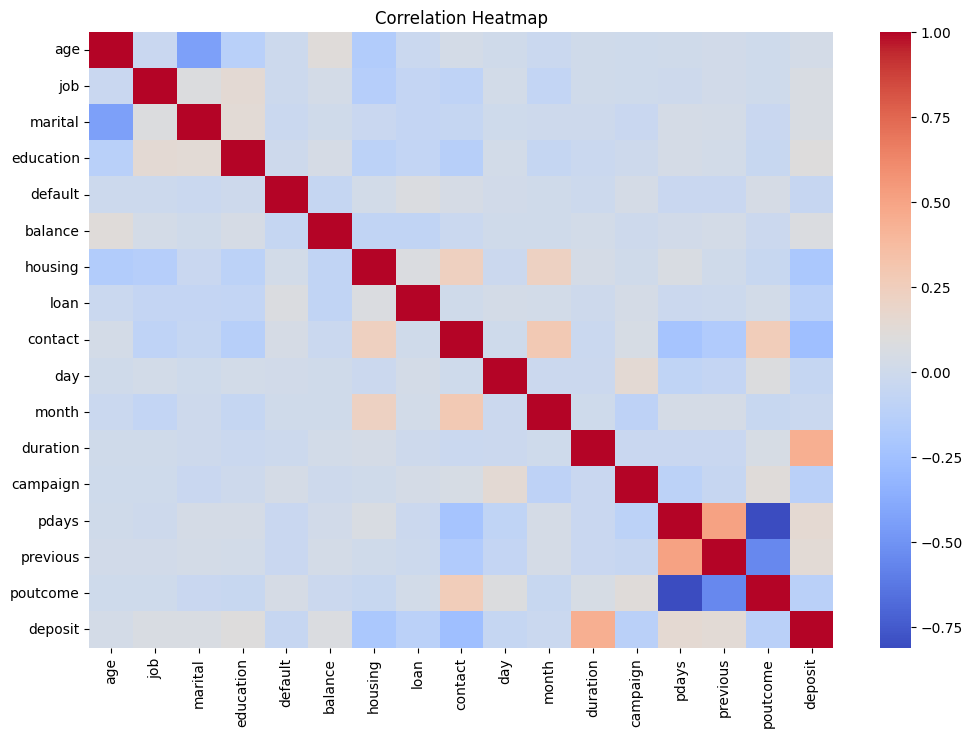

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [30]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [31]:
X = df.drop('deposit', axis=1)

y = df['deposit']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [34]:
knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance'
)

knn.fit(X_train, y_train)

,n_neighbors,7
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [35]:
y_pred_knn = knn.predict(X_test)

In [36]:
print("KNN Accuracy :")

print(accuracy_score(y_test, y_pred_knn))

KNN Accuracy :
0.7767807066741447


In [37]:
nb = GaussianNB()

nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [38]:
y_pred_nb = nb.predict(X_test)

In [39]:
print("Naive Bayes Accuracy :")

print(accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy :
0.7431295569265284


In [40]:
log_model = LogisticRegression(
    max_iter=2000
)

log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [41]:
y_pred_log = log_model.predict(X_test)

In [42]:
print("Logistic Regression Accuracy :")

print(accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy :
0.7913628715647785


In [43]:
svm = SVC(
    kernel='rbf',
    C=10
)

svm.fit(X_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [44]:
y_pred_svm = svm.predict(X_test)

In [45]:
print("SVM Accuracy :")

print(accuracy_score(y_test, y_pred_svm))

SVM Accuracy :
0.8104318564217611


In [46]:
models = pd.DataFrame({

    'Model': [
        'KNN',
        'Naive Bayes',
        'Logistic Regression',
        'SVM'
    ],

    'Accuracy': [

        accuracy_score(y_test, y_pred_knn),

        accuracy_score(y_test, y_pred_nb),

        accuracy_score(y_test, y_pred_log),

        accuracy_score(y_test, y_pred_svm)
    ]
})

models

,Model,Accuracy
0,KNN,0.776781
1,Naive Bayes,0.743130
2,Logistic Regression,0.791363
3,SVM,0.810432


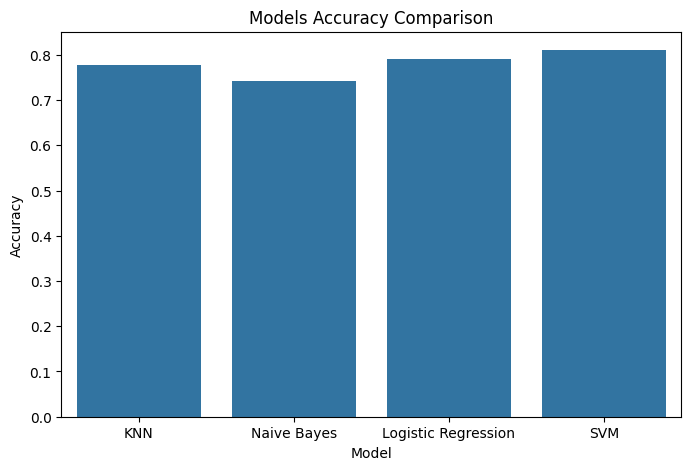

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=models
)

plt.title('Models Accuracy Comparison')

plt.show()